# Data cleaning & Preprocessing

> TODO adicionar descrição breve sobre o que fiz

## Data cleaning

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import missingno as msno
sns.set_theme(style='darkgrid')
import matplotlib.pyplot as plt

In [2]:
data = pd.read_excel('Assignment/DataSets/UCMF.xls')

data = data.rename(columns={
    'IDADE': 'Idade',
    'PULSOS':'Pulsos',
    'PA SISTOLICA': 'SBP',
    'PA DIASTOLICA': 'DBP',
    'PPA': 'Result SBP-DBP',
    'NORMAL X ANORMAL': 'Patologia',
    'SOPRO' : 'Sopro',
    'SEXO':'Sexo',
    'HDA 1': 'HDA1',
    'MOTIVO1' : 'Motivo1',
    'MOTIVO2': 'Motivo2'
})

In [3]:
data.columns

Index(['ID', 'Peso', 'Altura', 'IMC', 'Atendimento', 'DN', 'Idade', 'Convenio',
       'Pulsos', 'SBP', 'DBP', 'Result SBP-DBP', 'Patologia', 'B2', 'Sopro',
       'FC', 'HDA1', 'HDA2', 'Sexo', 'Motivo1', 'Motivo2'],
      dtype='object')

### Remove Irrelevant features

In [4]:
data = data.drop(['ID','Atendimento','DN','Convenio'],axis=1)

In [5]:
data.columns

Index(['Peso', 'Altura', 'IMC', 'Idade', 'Pulsos', 'SBP', 'DBP',
       'Result SBP-DBP', 'Patologia', 'B2', 'Sopro', 'FC', 'HDA1', 'HDA2',
       'Sexo', 'Motivo1', 'Motivo2'],
      dtype='object')

### Filter records with desired target group age (2-19)

In [6]:
data.shape

(17873, 17)

In [7]:

data = data[data['Idade'] != '#!VALUE!']
data = data[data['Idade'] != '#VALUE!']

In [8]:
data.shape

(17753, 17)

In [9]:
data['Idade'] = data['Idade'].astype(float)


In [10]:
data['Idade'] = data['Idade'].abs()

In [11]:
data = data[data['Idade'].between(2,19)]
data.shape

(12384, 17)

In [12]:
data['Idade'] = data['Idade'].astype(int)


In [13]:
data['Idade'].value_counts

<bound method IndexOpsMixin.value_counts of 2         4
4         9
5         4
6        12
7         5
         ..
17862    12
17863     8
17865     8
17867     2
17872    11
Name: Idade, Length: 12384, dtype: int64>

### Handle Inconsistent values

In [14]:
# Patologia
print("(Before)", data['Patologia'].value_counts())
map = {
    'anormal': 'Anormal',
    'Normais': 'Normal'
}
data['Patologia'] = data['Patologia'].replace(map)
print("(After)", data['Patologia'].value_counts())



(Before) Patologia
Normal     7768
Anormal    4315
anormal       1
Normais       1
Name: count, dtype: int64
(After) Patologia
Normal     7769
Anormal    4316
Name: count, dtype: int64


In [15]:
# Sexo
print("(Before)",data['Sexo'].value_counts())
data['Sexo'] = data['Sexo'].str.strip().str.capitalize()
map = {
    'M': 'Masculino',
    'F': 'Feminino'
}
data['Sexo'] = data['Sexo'].replace(map)
print("(After)", data['Sexo'].value_counts())

(Before) Sexo
M                6647
F                4884
Masculino         463
Feminino          178
Indeterminado     147
masculino          62
Name: count, dtype: int64
(After) Sexo
Masculino        7172
Feminino         5062
Indeterminado     147
Name: count, dtype: int64


In [16]:
# Pulsos
print("(Before)",data['Pulsos'].value_counts())
data['Pulsos'] = data['Pulsos'].str.strip().str.capitalize()
map = {
    'Normais': 'Normal',
    'NORMAIS': 'Normal',
    'Diminuídos': 'Diminished Femoral',
    'Femorais diminuidos': 'Diminished Femoral',
    'Amplos': 'Ample'
}
data['Pulsos'] = data['Pulsos'].replace(map)
print("(After)", data['Pulsos'].value_counts())


(Before) Pulsos
Normais                12019
Outro                     26
Amplos                    17
Femorais diminuidos        9
Diminuídos                 7
NORMAIS                    1
Name: count, dtype: int64
(After) Pulsos
Normal                12020
Outro                    26
Ample                    17
Diminished Femoral       16
Name: count, dtype: int64


In [17]:
# B2
print("(Before)",data['B2'].value_counts())
data['B2'] = data['B2'].str.strip().str.capitalize()
map = {
    'Única': 'Unique',
    'Desdob fixo': 'Fixed Split',
    'Hiperfonética': 'Hyperphonetic'
}
data['B2'] = data['B2'].replace(map)
print("(After)", data['B2'].value_counts())

(Before) B2
Normal           11729
Hiperfonética      136
Desdob fixo        115
Outro               79
Única               28
Name: count, dtype: int64
(After) B2
Normal           11729
Hyperphonetic      136
Fixed Split        115
Outro               79
Unique              28
Name: count, dtype: int64


In [18]:
# Sopro
print("(Before)",data['Sopro'].value_counts())
data['Sopro'] = data['Sopro'].str.strip().str.capitalize()
map = {
    'ausente': 'Ausente',
    'sistólico': 'Sistólico',
    'contínuo': 'Contínuo',
    'diastólico': 'Diastólico'
}
data['Sopro'] = data['Sopro'].replace(map)
print("(After)", data['Sopro'].value_counts())

(Before) Sopro
ausente                   8258
Sistólico                 3023
sistólico                  772
contínuo                    16
Contínuo                    13
diastólico                   8
Sistolico e diastólico       2
Name: count, dtype: int64
(After) Sopro
Ausente                   8258
Sistólico                 3795
Contínuo                    29
Diastólico                   8
Sistolico e diastólico       2
Name: count, dtype: int64


In [19]:
# Motivo1
data['Motivo1'].value_counts()
print("(Before)",data['Motivo1'].value_counts())
map = {
    '5 - Parecer cardiológico' : 'Triagem Cardiológica',
    '6 - Suspeita de cardiopatia': 'Possivel cardiopatia',
    '2 - Check-up' : 'Checkup de rotina',
    '1 - Cardiopatia já estabelecida': 'Cardiopatia',
    '7 - Outro' : 'Outros'
}
data['Motivo1'] = data['Motivo1'].replace(map)
print("(After)", data['Motivo1'].value_counts())

(Before) Motivo1
5 - Parecer cardiológico           6472
6 - Suspeita de cardiopatia        3917
2 - Check-up                        789
1 - Cardiopatia já estabelecida     784
7 - Outro                           314
Name: count, dtype: int64
(After) Motivo1
Triagem Cardiológica    6472
Possivel cardiopatia    3917
Checkup de rotina        789
Cardiopatia              784
Outros                   314
Name: count, dtype: int64


In [20]:
# Motivo2
data['Motivo2'].value_counts()
print("(Before)",data['Motivo2'].value_counts())
map = {
    '5 - Cirurgia': 'Cirurgia',
    '6 - Sopro' : 'Presença de Sopro',
    '5 - Atividade física' : 'Atividade física',
    'Outro' : 'Outros',
    '1 - Cardiopatia congenica' : 'Cardiopatia congenica',
    '6 - Dor precordial' : 'Outros',
    '6 - Palpitação/taquicardia/arritmia' : 'Outros',
    '6 - HAS/dislipidemia/obesidade' : 'Fatores de risco',
    '6 - Dispnéia' : 'Outros',
    '1 - Cardiopatia adquirida' :'Outros',
    '6 - Cianose' : 'Outros',
    '6 - Cardiopatia na familia' : 'Fatores de risco',
    '6 - Cansaço' : 'Outros',
    '6 - Alterações de pulso/perfusão' : 'Outros',
    '6 - Cianose e dispnéia' : 'Outros',
    '5 - Uso de cisaprida' : 'Outros'

}
data['Motivo2'] = data['Motivo2'].replace(map)
print("(After)", data['Motivo2'].value_counts())


(Before) Motivo2
5 - Cirurgia                           3352
6 - Sopro                              1721
5 - Atividade física                   1069
Outro                                   720
1 - Cardiopatia congenica               639
6 - Dor precordial                      616
6 - Palpitação/taquicardia/arritmia     452
6 - HAS/dislipidemia/obesidade          396
6 - Dispnéia                            240
1 - Cardiopatia adquirida               112
6 - Cianose                              51
6 - Cardiopatia na familia               31
6 - Cansaço                              16
6 - Alterações de pulso/perfusão          2
6 - Cianose e dispnéia                    2
5 - Uso de cisaprida                      1
Name: count, dtype: int64
(After) Motivo2
Cirurgia                 3352
Outros                   2212
Presença de Sopro        1721
Atividade física         1069
Cardiopatia congenica     639
Fatores de risco          427
Name: count, dtype: int64


### Remove incorect/impossible/irrelevant values

In [21]:
# Remover objectos com valores incorrectos de SBP (da-mos uma 'folga' de 10 para
# limite superior e inferior)
import json
with open('Assignment/Data-structures/sbp-dbp-reference-values-map.json', 'r') as file:
    sbp_map = json.load(file)

print(f'(Before removing incorret Male/Female SBP Values) {data.shape} ')

# Remover valores SBP invalidos para sexo Masculino
indices_to_drop = []
for index, row in data[data['Sexo'] == 'Masculino'].iterrows():
    idade = str(int(row['Idade']))
    sbp = row['SBP']
    lower_limit = float(sbp_map['M'][idade]['SBP'][0] - 10)
    upper_limit = float(sbp_map['M'][idade]['SBP'][1] + 10)
    if (sbp < lower_limit or sbp > upper_limit):
        indices_to_drop.append(index)
        
data = data.drop(indices_to_drop)
print(f'Male entries removed {len(indices_to_drop)}')

# Remover valores SBP invalidos para sexo Feminino
indices_to_drop = []
for index, row in data[data['Sexo'] == 'Feminino'].iterrows():
    idade = str(int(row['Idade']))
    sbp = row['SBP']
    lower_limit = float(sbp_map['F'][idade]['SBP'][0] - 10)
    upper_limit = float(sbp_map['F'][idade]['SBP'][1] + 10)
    if (sbp < lower_limit or sbp > upper_limit):
        indices_to_drop.append(index)
        
data = data.drop(indices_to_drop)

print(f'Female Entries removed {len(indices_to_drop)}')
print(f'(After removing incorret Male/Female SBP Values) {data.shape} ')

(Before removing incorret Male/Female SBP Values) (12384, 17) 
Male entries removed 206
Female Entries removed 143
(After removing incorret Male/Female SBP Values) (12035, 17) 


In [22]:
# Remover objectos com valores incorrectos de DBP (da-mos uma 'folga' de 10 para
# limite superior e inferior)
import json
with open('Assignment/Data-structures/sbp-dbp-reference-values-map.json', 'r') as file:
    dbp_map = json.load(file)

print(f'(Before removing incorret Male/Female DBP Values) {data.shape} ')

# Remover valores DBP invalidos para sexo Masculino
indices_to_drop = []
for index, row in data[data['Sexo'] == 'Masculino'].iterrows():
    idade = str(int(row['Idade']))
    dbp = row['DBP']
    lower_limit = float(dbp_map['M'][idade]['DBP'][0] - 10)
    upper_limit = float(dbp_map['M'][idade]['DBP'][1] + 10)
    if (dbp < lower_limit or dbp > upper_limit):
        indices_to_drop.append(index)
        
data = data.drop(indices_to_drop)
print(f'Male entries removed {len(indices_to_drop)}')

# Remover valores DBP invalidos para sexo Feminino
indices_to_drop = []
for index, row in data[data['Sexo'] == 'Feminino'].iterrows():
    idade = str(int(row['Idade']))
    dbp = row['DBP']
    lower_limit = float(dbp_map['F'][idade]['DBP'][0] - 10)
    upper_limit = float(dbp_map['F'][idade]['DBP'][1] + 10)
    if (dbp < lower_limit or dbp > upper_limit):
        indices_to_drop.append(index)
        
data = data.drop(indices_to_drop)

print(f'Female Entries removed {len(indices_to_drop)}')
print(f'(After removing incorret Male/Female DBP Values) {data.shape} ')

(Before removing incorret Male/Female DBP Values) (12035, 17) 
Male entries removed 19
Female Entries removed 29
(After removing incorret Male/Female DBP Values) (11987, 17) 


In [23]:
# Remover objectos com valores imposiveis de peso 
print(f'Before removing impossible Weight values {data.shape}')
data = data.drop(data[data['Peso'] <= 0].index)
print(f'After removing impossible Weight values {data.shape}')


Before removing impossible Weight values (11987, 17)
After removing impossible Weight values (10759, 17)


In [24]:
# Remover objectos com valores imposiveis de Altura 
print(f'Before removing impossible Heigth values {data.shape}')
data = data.drop(data[data['Altura'] <=0].index)
print(f'After removing impossible Heigth values {data.shape}')



Before removing impossible Heigth values (10759, 17)
After removing impossible Heigth values (9554, 17)


In [25]:
# Remover Pulsos = Outro
print(f'Before removing irrelevant Pulsos values {data.shape}')
data = data.drop(data[data['Pulsos'] == 'Outro'].index)
print(f'After removing irrelevant Pulsos values {data.shape}')


Before removing irrelevant Pulsos values (9554, 17)
After removing irrelevant Pulsos values (9541, 17)


> Removed objects with ```Pulsos = Outro```, this value gives no info about the Pulse related to the object, so we removed because we think this objects  will not help our prediction task

In [26]:
# Remover valores B2 = Outro
print(f'Before removing irrelevant B2 values {data.shape}')
data = data.drop(data[data['B2'] == 'Outro'].index)
print(f'After removing irrelevant B2 values {data.shape}')


Before removing irrelevant B2 values (9541, 17)
After removing irrelevant B2 values (9483, 17)


> Removed objects with ```B2 = Outro```, because this value gives no info about the type of the second heart sound related to the object, so we removed because we think this objects will not help our prediction task

In [27]:
# Remover valores Sopro = Sistolico e diastólico 
print(f'Before removing irrelevant Sopro values {data.shape}')
data = data.drop(data[data['Sopro'] == 'Sistolico e diastólico'].index)
print(f'After removing irrelevant Sopro values {data.shape}')

Before removing irrelevant Sopro values (9483, 17)
After removing irrelevant Sopro values (9482, 17)


> Removed objects with ```Sopro = Sistolico e diastólico```, because it just one object with this value, and we think it will not help our prediction task

In [28]:
# Ajustar unico valor HDA2 = Assintomático e passar para HDA1 = Assintomático
print(data['HDA2'].value_counts())

data.loc[data['HDA2'] == 'Assintomático', 'HDA1'] = 'Assintomático'
data.loc[data['HDA2'] == 'Assintomático', 'HDA2'] = np.nan
print(data['HDA2'].value_counts())

HDA2
Palpitacao         99
Dispneia           73
Dor precordial     67
Desmaio/tontura    48
Outro              36
Cianose            33
Ganho de peso      26
Assintomático       1
Name: count, dtype: int64
HDA2
Palpitacao         99
Dispneia           73
Dor precordial     67
Desmaio/tontura    48
Outro              36
Cianose            33
Ganho de peso      26
Name: count, dtype: int64


In [29]:
# Remover valores HDA1 = Outro e HDA2 = Outro
print(f'Before removing irrelevant HDA1 and HDA2 values {data.shape}')
data = data.drop(data[data['HDA1'] == 'Outro'].index)
data = data.drop(data[data['HDA2'] == 'Outro'].index)
print(f'After removing irrelevant HDA1 and HDA2 values {data.shape}')


Before removing irrelevant HDA1 and HDA2 values (9482, 17)
After removing irrelevant HDA1 and HDA2 values (9325, 17)


> Removed objects with ```HDA1 = Outro``` and ```HDA2 = Outro```, because the information about history of disease it provides is to ambiguos. Having this in mind, we think this objects will not help de prediction task, so we removed them

In [30]:
# Remover valores Sexo = Indeterminado 
print(f'Before removing irrelevant Sexo values {data.shape}')
data = data.drop(data[data['Sexo'] == 'Indeterminado'].index)
print(f'After removing irrelevant Sexo values {data.shape}')

Before removing irrelevant Sexo values (9325, 17)
After removing irrelevant Sexo values (9215, 17)


> Removed objects with ```Sexo = Indeterminado```, because it does not give any info about the patient sex, therefore it does not bring any value to the prediction task 

In [31]:
# Ajustar coluna FC para ser numérica 
# Tenta converter para número. O que tiver letras vira NaN (errors='coerce')
data['FC'] = pd.to_numeric(data['FC'], errors='coerce')

In [32]:
# Remover objetos de Frequencia impossiveis
import json
with open('Assignment/Data-structures/fc-reference-values.json', 'r') as file:
    fc_map = json.load(file)

json.dumps(fc_map)

print(f'(Before removing invalid FC Values) {data.shape} ')

# Remover valores SBP invalidos para sexo Feminino
indices_to_drop = []
for index, row in data.iterrows():
    card_freq = row['FC']

    idade = str(int(row['Idade']))
    min_freq = fc_map[idade]['bpm_minimo'] - 5.0
    max_freq = fc_map[idade]['bpm_maximo'] + 5.0
    if (~np.isnan(card_freq)):
        if(card_freq < min_freq or card_freq > max_freq):
            indices_to_drop.append(index)

data = data.drop(indices_to_drop)
print(f'(After removing invalid FC Values) {data.shape} ')

(Before removing invalid FC Values) (9215, 17) 
(After removing invalid FC Values) (8995, 17) 


### Address Missing Values

Deleting variables (columns) or objects (rows) that contain more than 50% missing values, provided the missing data has no inherent meaning. 

* Columns ```where a NaN has meaning```: 
    * **Sopro**: we assume it means there is no **murmur type** present (i.e. NaN in Sopro actualy means that is has values = **Ausente**)
    * **HDA1**, **HDA2** : we assume that there is no history of disease (i.e. NaN in HDA1 or HDA2 means that is value is Assintomático)
    * **Motivo1**, **Motivo2**: we assume that there is no motive (i.e. NaN in Motivo1 or Motivo2 means that is values is Outro )
 
* Columns ```where a NaN has no meaning```, and why we can remove: 
    * **Peso** : it means that the Weight wasnt measured, and therefore these objects don't help in our prediction task
    * **Altura** : it means that the Height wasnt measured, and therefore these objects don't help in our prediction task

    * **Pulsos** : it means that the Pulsos wasnt measured, and therefore these objects don't help in our prediction task
    * **SBP** and **DBP**: it means that the DBP and DBP werent measured, and therefore these objects don't help in our prediction task
    * **Patologia**: We cant be sure if NaN  means Anormal or Normal, so we the safest aproach is to assume it has no meaning
    * **B2**: it means that the type of the second heart sound wasnt measured, and therefore these objects don't help in our prediction task
    * **FC**: it means that the Cardiac Frequency wasnt measured, and therefore these objects don't help in our prediction task
    * **Sexo**: it means that Sex wasnt indicated, and therefore these objects don't help in our prediction task

* ```Important Note```:
    * **Result SBP-DBP**: No need to remove NaN because we are going to use the SBP and DBP values to recalculate all values of this column
    * **IMC** : No need to remove NaN because we are going to use the Peso and Altura values to recalculate all values of this column



In [33]:
# Columns that the NaN has no meaning and the respectiv object can be removed
columns_remove_NaN = ['Peso','Altura','Pulsos','SBP','DBP','Patologia','B2','FC','Sexo']
print(f'(Before removing objects wiht missing Values with no meaning) {data.shape} ')
for col in columns_remove_NaN:
    data = data.dropna(subset=[col])
    print(f' Number of  objects(rows) after removing NaN from {col} : {len(data)} ')
print(f'(After removing objects wiht missing Values with no meaning) {data.shape} ')


(Before removing objects wiht missing Values with no meaning) (8995, 17) 
 Number of  objects(rows) after removing NaN from Peso : 8831 
 Number of  objects(rows) after removing NaN from Altura : 8831 
 Number of  objects(rows) after removing NaN from Pulsos : 8576 
 Number of  objects(rows) after removing NaN from SBP : 6670 
 Number of  objects(rows) after removing NaN from DBP : 6666 
 Number of  objects(rows) after removing NaN from Patologia : 6658 
 Number of  objects(rows) after removing NaN from B2 : 6657 
 Number of  objects(rows) after removing NaN from FC : 6359 
 Number of  objects(rows) after removing NaN from Sexo : 6358 
(After removing objects wiht missing Values with no meaning) (6358, 17) 


In [34]:
# Columns that the NaN has meaning, and the NaN need to be swicthed for a proper value
columns_alter_NaN = ['Sopro','HDA1','HDA2','Motivo1','Motivo2']
cor_NaN_value = ['Ausente','Assintomático','Assintomático','Outros','Outros']
print(f'(Before altering objects wiht missing Values with meaning) {data.shape} ')

i=0
for col in columns_alter_NaN:
    print(" (Before)" ,data[col].value_counts())
    data[col] = data[col].fillna(cor_NaN_value[i])
    print(" (After)" ,data[col].value_counts())
    i+=1


print(f'(After altering objects wiht missing Values with meaning) {data.shape} ')



(Before altering objects wiht missing Values with meaning) (6358, 17) 
 (Before) Sopro
Ausente       4410
Sistólico     1938
Contínuo         6
Diastólico       4
Name: count, dtype: int64
 (After) Sopro
Ausente       4410
Sistólico     1938
Contínuo         6
Diastólico       4
Name: count, dtype: int64
 (Before) HDA1
Assintomático      3584
Dor precordial      478
Dispneia            286
Palpitacao          255
Desmaio/tontura     151
Ganho de peso       118
Cianose              45
Name: count, dtype: int64
 (After) HDA1
Assintomático      5025
Dor precordial      478
Dispneia            286
Palpitacao          255
Desmaio/tontura     151
Ganho de peso       118
Cianose              45
Name: count, dtype: int64
 (Before) HDA2
Palpitacao         86
Dispneia           62
Dor precordial     51
Desmaio/tontura    34
Cianose            25
Ganho de peso      22
Name: count, dtype: int64
 (After) HDA2
Assintomático      6078
Palpitacao           86
Dispneia             62
Dor precordial    

In [35]:
missing_data = pd.DataFrame({
    'Coluna': data.columns,
    'Percentagem (%)': (data.isnull().mean() * 100).values
}).sort_values('Percentagem (%)', ascending=False)

print(missing_data)


            Coluna  Percentagem (%)
7   Result SBP-DBP         0.802139
0             Peso         0.000000
1           Altura         0.000000
3            Idade         0.000000
2              IMC         0.000000
4           Pulsos         0.000000
5              SBP         0.000000
6              DBP         0.000000
8        Patologia         0.000000
9               B2         0.000000
10           Sopro         0.000000
11              FC         0.000000
12            HDA1         0.000000
13            HDA2         0.000000
14            Sexo         0.000000
15         Motivo1         0.000000
16         Motivo2         0.000000


### Remove duplicates

In [36]:
print(f"Before removing duplicate lines {data.shape}")
data = data.drop_duplicates()
print(f"After removing duplicate lines {data.shape}")

Before removing duplicate lines (6358, 17)
After removing duplicate lines (6321, 17)


### Handling Outliers

We decided to maintain outliers for columns were they do not represent impossible values, and give valid patient information. The columns that have outliers with impossible values, we removed it.

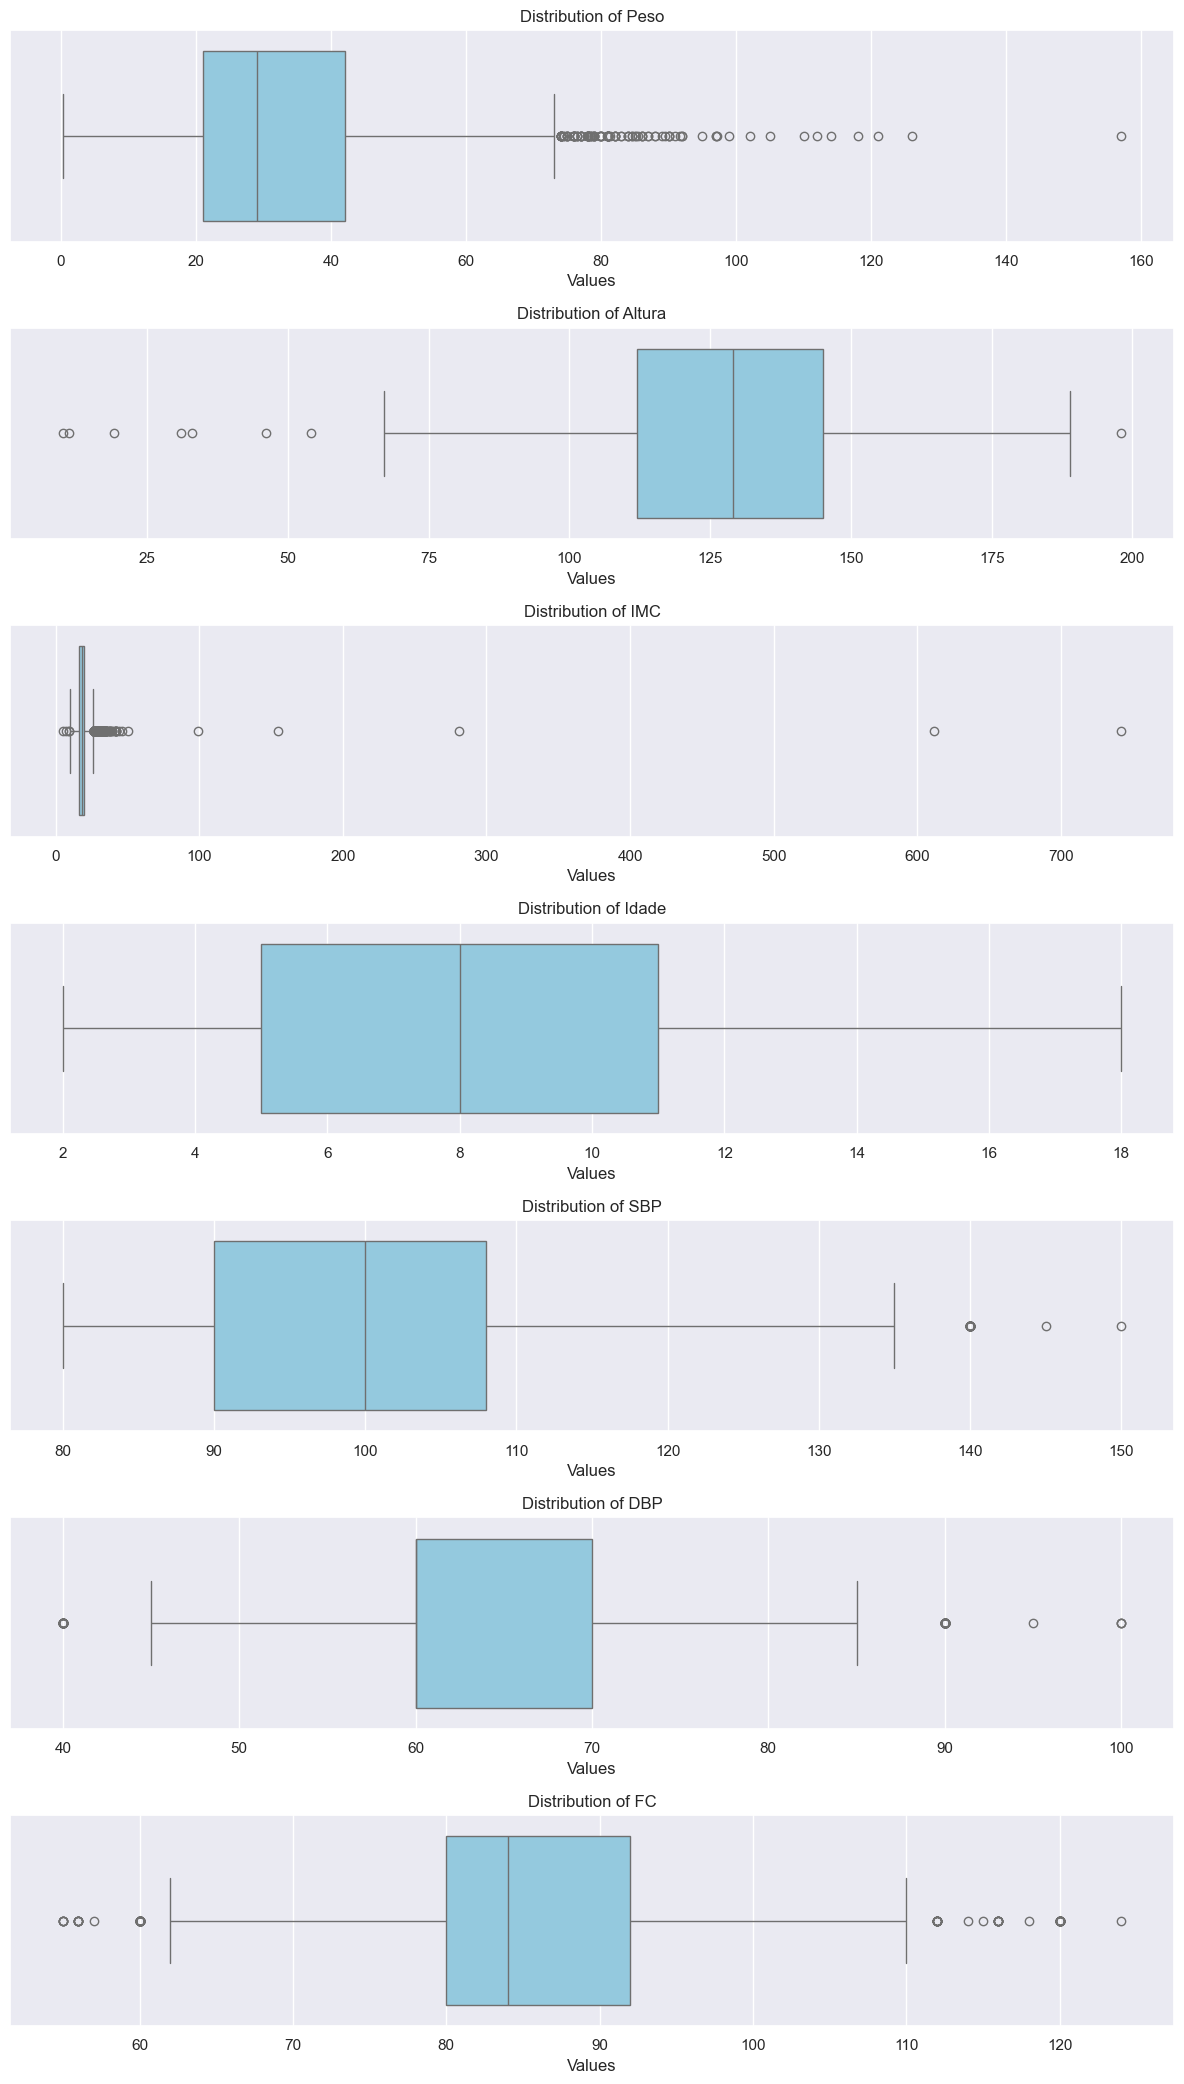

In [37]:
cols = data.select_dtypes(include=['number']).columns
rows = len(cols)

# Criamos uma coluna por linha para que fiquem bem largos na horizontal
fig, axes = plt.subplots(rows, 1, figsize=(12, rows * 3))

# Garantir que axes seja uma lista mesmo que haja apenas uma coluna
if rows == 1: axes = [axes]

for i, col in enumerate(cols):
    # Passar a coluna para o parâmetro 'x' torna-o horizontal
    sns.boxplot(x=data[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Values')

plt.tight_layout()
plt.show()

In [38]:
import json
with open('Assignment/Data-structures/height_percentiles.json', 'r') as file:
    height_data = json.load(file)


def filtrar_altura_inconsistente(row):
    idade = str(int(row['Idade']))
    sexo = 'female' if row['Sexo'] == 'Feminino' else 'male'
    
    # Exemplo usando o JSON de altura que criámos
    if sexo in height_data and idade in height_data[sexo]:
        p5 = height_data[sexo][idade]['p5']
        p95 = height_data[sexo][idade]['p95']
        
        # Se a altura for 30% menor que o P5 ou 30% maior que o P95, é provável erro
        if row['Altura'] < (p5 * 0.7) or row['Altura'] > (p95 * 1.3):
            return False
    return True


print(f"Before handling Altura outliers {data.shape}")
data = data[data.apply(filtrar_altura_inconsistente, axis=1)]
print(f"After handling Altura outliers {data.shape}")

Before handling Altura outliers (6321, 17)
After handling Altura outliers (6301, 17)


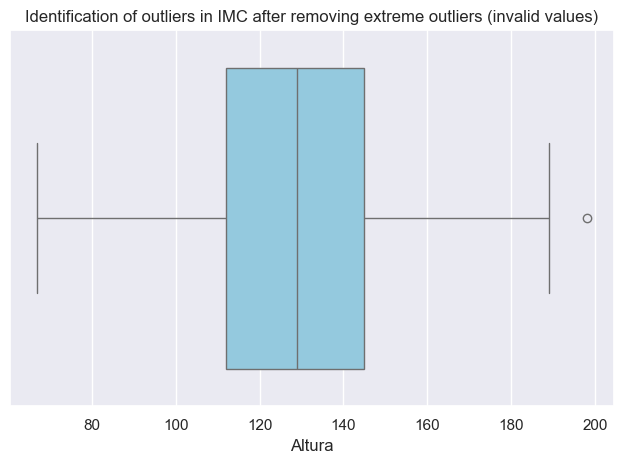

In [39]:
sns.boxplot(x=data['Altura'],color='skyblue')
plt.title('Identification of outliers in IMC after removing extreme outliers (invalid values)')
plt.tight_layout()
plt.show()    

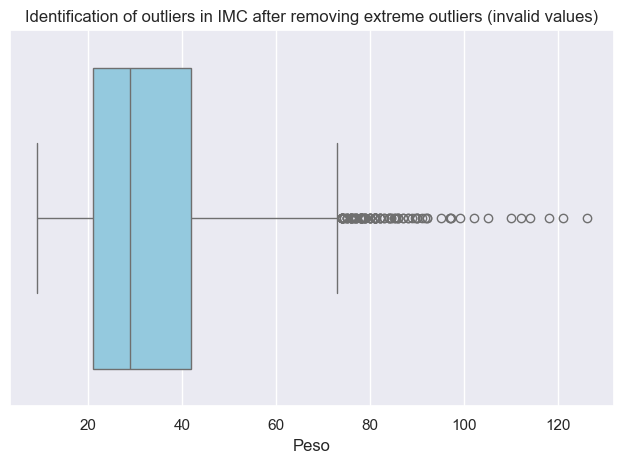

In [40]:
sns.boxplot(x=data['Peso'],color='skyblue')
plt.title('Identification of outliers in IMC after removing extreme outliers (invalid values)')
plt.tight_layout()
plt.show()    

## Data Preprocessing

### Feature construction / Generalization

Create new features with existing features

In [41]:
# Recalcular Result SBP 
import json
with open('Assignment/Data-structures/height_percentiles.json', 'r') as file:
    height_data = json.load(file)
with open('Assignment/Data-structures/bp_thresholds.json', 'r') as file:
    bp_data = json.load(file)


def get_height_percentile(sex, age, height_cm):
    """Determina o percentil de altura mais próximo."""
    age_str = str(age)
    options = height_data[sex][age_str]
    
    # Encontra o percentil onde a altura do paciente é menor ou igual ao limite
    # Para ser conservador, se estiver entre dois, escolhemos o mais alto.
    chosen_p = "95" # Default para crianças muito altas
    for p in ["p5", "p10", "p25", "p50", "p75", "p90", "p95"]:
        if height_cm <= options[p]:
            chosen_p = p.replace("p", "")
            break
    return chosen_p


def classify_pediatric_bp(sex, age, height_cm, sbp, dbp):
    """Classifica a PA com base na idade, sexo e altura."""
    age_str = str(age)
    
    # Passo 1: Obter o percentil de altura
    h_p = get_height_percentile(sex, age, height_cm)
    
    # Passo 2: Obter os limites de BP para esse percentil
    thresholds = bp_data[sex][age_str][h_p]
    
    # Passo 3: Lógica de classificação (PAS OU PAD)
    # HAS se >= P95 [cite: 601, 608]
    if sbp >= thresholds["SBP"]["p95"] or dbp >= thresholds["DBP"]["p95"]:
        result = "Hipertenso"
    # Pré-hipertenso se entre P90 e P95 
    elif sbp >= thresholds["SBP"]["p90"] or dbp >= thresholds["DBP"]["p90"]:
        result = "Pre-hipertenso"
    else:
        result = "Normal" 
        
    return {
        "Status": result,
        "Percentil Altura": h_p,
        "Limites Aplicados (P90/P95)": {
            "SBP": f"{thresholds['SBP']['p90']}/{thresholds['SBP']['p95']}",
            "DBP": f"{thresholds['DBP']['p90']}/{thresholds['DBP']['p95']}"
        }
    }
# print("Exemplo 1:", classify_pediatric_bp("female", 10, 139, 110, 70)['Status'])


for index, row in data.iterrows():
    sexo = 'female' if row['Sexo'] == 'Feminino' else 'male'
    idade = int(row['Idade'])
    altura_cm = row['Altura']
    sbp = int(row['SBP'])
    dbp = int(row['DBP'])
    if idade <= 17:
        status_final = classify_pediatric_bp(sexo,idade,altura_cm,sbp,dbp)['Status']
        data.at[index, 'Result SBP-DBP'] = status_final
    else:
        # https://www.ncbi.nlm.nih.gov/books/NBK9633/table/A32/
        if sbp >= 140 or dbp >= 90:
            status_final = "Hipertenso"
        elif sbp >= 120 or dbp >= 80:
            status_final = "Pre-hipertenso"
        else:
            status_final = "Normal"
        data.at[index, 'Result SBP-DBP'] = status_final

    

<Axes: >

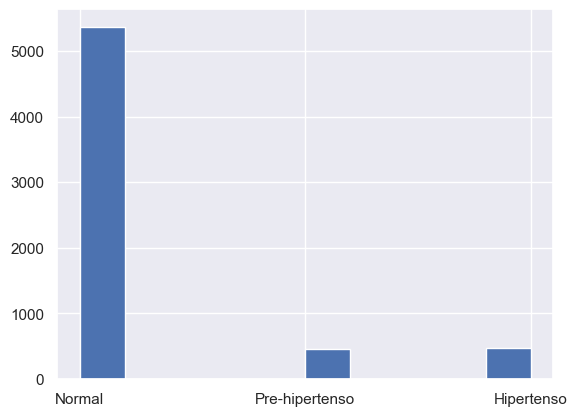

In [42]:
data['Result SBP-DBP'].hist()

In [43]:
# Recalcular IMC
data.columns
for index, row in data.iterrows():
    peso = row['Peso']
    altura_m = row['Altura']/100
    imc = round(peso / (altura_m**2),2)
    data.at[index, 'IMC'] = imc


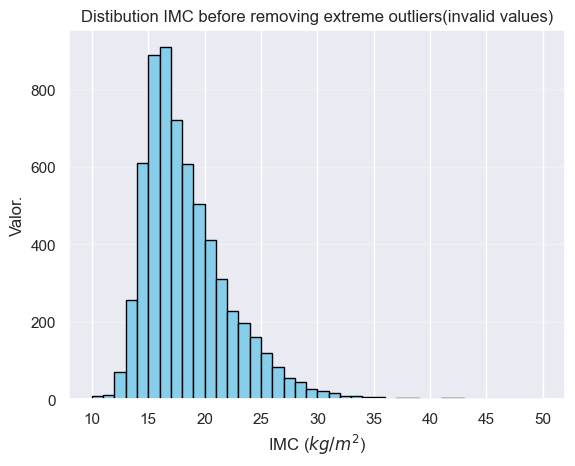

In [44]:
plt.hist(data['IMC'], bins=40, range=(10, 50), color='skyblue', edgecolor='black')

plt.title('Distibution IMC before removing extreme outliers(invalid values)')
plt.xlabel('IMC ($kg/m^2$)')
plt.ylabel('Valor.')
plt.grid(axis='y', alpha=0.3)
plt.show()

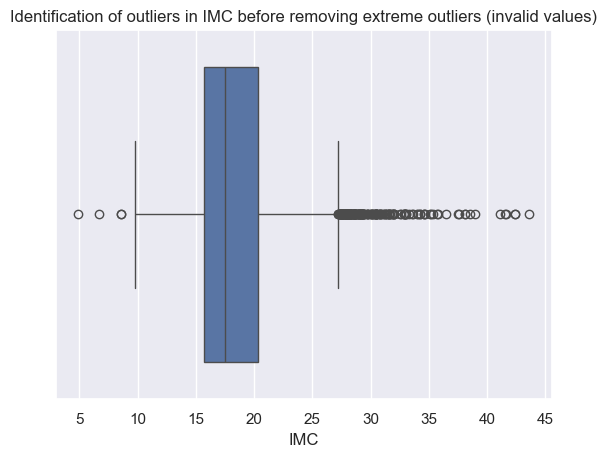

In [45]:
sns.boxplot(x=data['IMC'])
plt.title('Identification of outliers in IMC before removing extreme outliers (invalid values)')
plt.show()

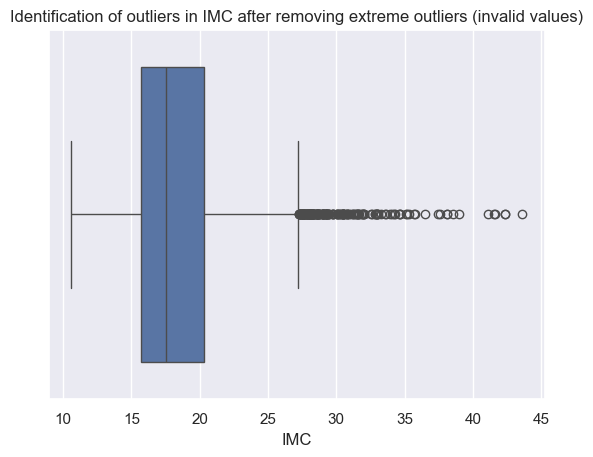

In [46]:
data = data[(data['IMC'] >= 10) & (data['IMC'] <= 100)]
sns.boxplot(x=data['IMC'])
plt.title('Identification of outliers in IMC after removing extreme outliers (invalid values)')
plt.show()

In [47]:
print(data['DBP'].min())
print(data['DBP'].max())

40.0
100.0


In [48]:
data.select_dtypes(include='number').columns.tolist()


['Peso', 'Altura', 'IMC', 'Idade', 'SBP', 'DBP', 'FC']

In [ ]:
# Feauture Categorica : Intervalo Idade
bins = [2, 6, 10, 14, 19]
labels = ['Pre-School [2,6[', 'School [6-10[', 'Pre-Teen [10,14[', 'Teenager [14,19[']
# right=False garante que o intervalo seja [2, 6[, [6, 10[, etc.
data['Intervalo Idade'] = pd.cut(data['Idade'], bins=bins, labels=labels, right=False)
print(data[['Idade', 'Intervalo Idade']].head())

    Idade   Intervalo Idade
4       9     School [6-10[
5       4  Pre-School [2,6[
7       5  Pre-School [2,6[
10      6     School [6-10[
16      2  Pre-School [2,6[


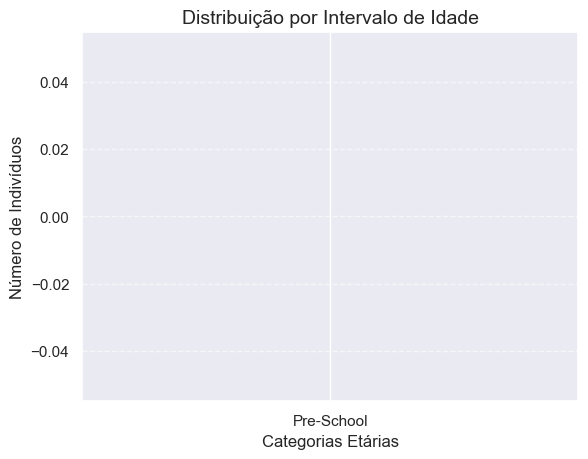

In [50]:
contagem = data['Intervalo Idade'].value_counts().reindex(['Pre-School', 'School', 'Pre-Teen', 'Teenager'])

plt.bar(contagem.index, contagem.values, color=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2'], edgecolor='black')

plt.title('Distribuição por Intervalo de Idade', fontsize=14)
plt.xlabel('Categorias Etárias', fontsize=12)
plt.ylabel('Número de Indivíduos', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

In [51]:
# Feauture Categorica : Percentil IMC
import json
with open('Assignment/Data-structures/bmi-references-values.json', 'r') as f:
    bmi_refs = json.load(f)

for index, row in data.iterrows():
    # Mapear o sexo para as chaves do JSON (F ou M)
    sexo_key = 'F' if row['Sexo'] == 'Feminino' else 'M'
    idade = int(row['Idade'])
    imc_atual = row['IMC']
    
    # Encontrar a referência para a idade e sexo específicos
    ref_row = next((item for item in bmi_refs['BMI'][sexo_key] if item['age_years'] == idade), None)
    
    status_imc = "Indeterminado"
    
    if ref_row:
        # Lógica de classificação baseada na Circular Normativa 
        if imc_atual >= ref_row['p95']:
            status_imc = 'Obese' # IMC acima do percentil 95 
        elif imc_atual >= ref_row['p85']:
            status_imc = 'Overweigth' # IMC entre o percentil 85 e 95 
        elif imc_atual < ref_row['p5']:
            status_imc = 'Low Weigth' # Abaixo do limite de normalidade p5
        else:
            status_imc = 'Normal' # Entre p5 e p85
            
    # Guardar o resultado no DataFrame
    data.at[index, 'Percentil IMC'] = status_imc

# Verificar os primeiros resultados
print(data[['Idade', 'Sexo', 'IMC', 'Percentil IMC']].head())

    Idade       Sexo    IMC Percentil IMC
4       9  Masculino  19.59    Overweigth
5       4  Masculino  20.73         Obese
7       5   Feminino  20.45         Obese
10      6  Masculino  16.46        Normal
16      2   Feminino  13.26    Low Weigth


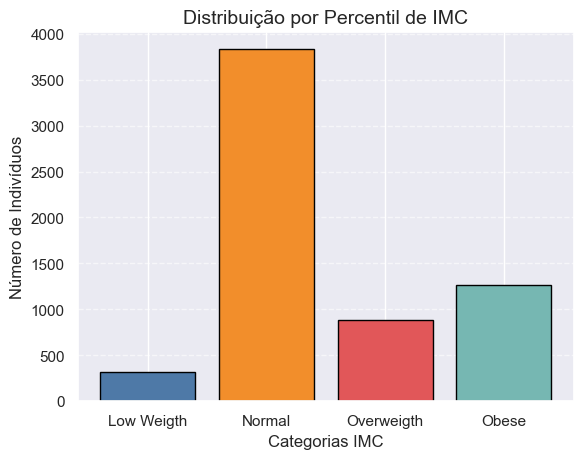

In [52]:
contagem = data['Percentil IMC'].value_counts().reindex(['Low Weigth', 'Normal', 'Overweigth', 'Obese'])

plt.bar(contagem.index, contagem.values, color=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2'], edgecolor='black')

plt.title('Distribuição por Percentil de IMC', fontsize=14)
plt.xlabel('Categorias IMC', fontsize=12)
plt.ylabel('Número de Indivíduos', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

In [53]:
# Feautures Categoricas : Systolic Blood Pressure (SBP) e Diastolic Blood Pressure (DBP)
import json

# Carregar os ficheiros necessários
with open('Assignment/Data-structures/bp_thresholds.json', 'r') as f:
    bp_thresholds = json.load(f)

with open('Assignment/Data-structures/height_percentiles.json', 'r') as file:
    height_data = json.load(file)

def get_height_percentile(sex, age, height_cm):
    """Determina o percentil de altura mais próximo."""
    age_str = str(age)
    # Verifica se a idade existe no ficheiro de altura (geralmente começa aos 2 anos)
    if age_str not in height_data[sex]:
        return "50" # Percentil padrão caso a idade não conste na tabela
        
    options = height_data[sex][age_str]
    chosen_p = "95" 
    for p in ["p5", "p10", "p25", "p50", "p75", "p90", "p95"]:
        if height_cm <= options[p]:
            chosen_p = p.replace("p", "")
            break
    return chosen_p

for index, row in data.iterrows():
    sexo = 'female' if row['Sexo'] == 'Feminino' else 'male'
    idade = int(row['Idade'])
    altura = row['Altura']
    sbp_atual = row['SBP']
    dbp_atual = row['DBP'] 
    
    classificacao = "Indeterminado"
    
    if idade >= 18:
        # https://www.ncbi.nlm.nih.gov/books/NBK9633/table/A32/

        if sbp_atual >= 140 or dbp_atual >= 90:
            classificacao = "Hipertenso"
        elif sbp_atual >= 120 or dbp_atual >= 80:
            classificacao = "Pre-Hipertenso"
        else:
            classificacao = "Normal"
    else: 
        # Lógica Pediatria (2-17 anos)
        h_p = get_height_percentile(sexo, idade, altura)
        idade_str = str(idade) # CORREÇÃO: Converter idade para String para o JSON
        
        try:
            # Aceder aos limites da Sistólica (SBP) usando chaves String
            limites_sbp = bp_thresholds[sexo][idade_str][h_p]['SBP']
            
            if sbp_atual >= limites_sbp['p95']:
                classificacao = 'Hipertenso'
            elif sbp_atual >= limites_sbp['p90']:
                classificacao = 'Pre-Hipertenso'
            else:
                classificacao = 'Normal'

            limites_dbp = bp_thresholds[sexo][idade_str][h_p]['DBP']
            if dbp_atual >= limites_dbp['p95']:
                classificacao = 'Hipertenso'
            elif dbp_atual >= limites_dbp['p90']:
                classificacao = 'Pre-Hipertenso'
            else:
                classificacao = 'Normal'


            
        except KeyError:
            # Caso a idade específica ou o percentil de altura não existam no JSON
            classificacao = "Indeterminado"
            
    # Guardar o resultado
    data.at[index, 'Systolic Blood Pressure (SBP)'] = classificacao
    data.at[index, 'Diastolic Blood Pressure (DBP)'] = classificacao

# Validar os resultados
print(data['Systolic Blood Pressure (SBP)'].value_counts())
print(data['Diastolic Blood Pressure (DBP)'].value_counts())

Systolic Blood Pressure (SBP)
Normal            5565
Pre-Hipertenso     406
Hipertenso         322
Name: count, dtype: int64
Diastolic Blood Pressure (DBP)
Normal            5565
Pre-Hipertenso     406
Hipertenso         322
Name: count, dtype: int64


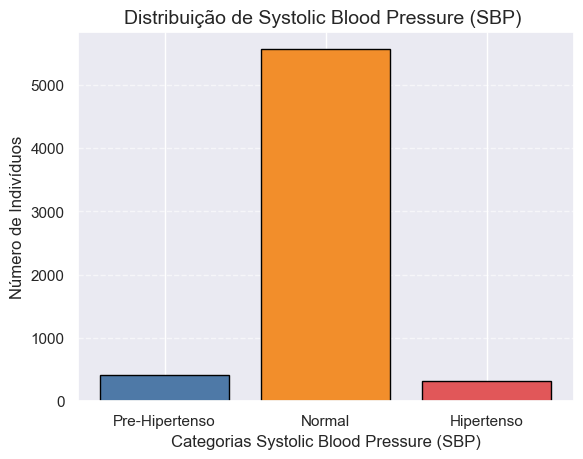

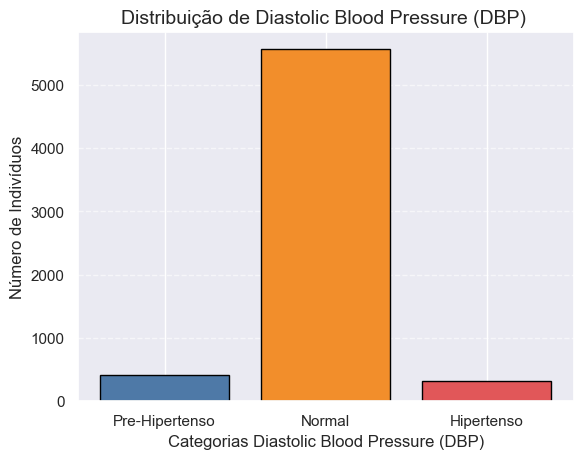

In [54]:
contagem = data['Systolic Blood Pressure (SBP)'].value_counts().reindex(['Pre-Hipertenso', 'Normal', 'Hipertenso'])

plt.bar(contagem.index, contagem.values, color=['#4e79a7', '#f28e2b', '#e15759', ], edgecolor='black')

plt.title('Distribuição de Systolic Blood Pressure (SBP) ', fontsize=14)
plt.xlabel('Categorias Systolic Blood Pressure (SBP)', fontsize=12)
plt.ylabel('Número de Indivíduos', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


contagem = data['Diastolic Blood Pressure (DBP)'].value_counts().reindex(['Pre-Hipertenso', 'Normal', 'Hipertenso'])

plt.bar(contagem.index, contagem.values, color=['#4e79a7', '#f28e2b', '#e15759', ], edgecolor='black')

plt.title('Distribuição de Diastolic Blood Pressure (DBP) ', fontsize=14)
plt.xlabel('Categorias Diastolic Blood Pressure (DBP)', fontsize=12)
plt.ylabel('Número de Indivíduos', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [55]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6293 entries, 4 to 17867
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   Peso                            6293 non-null   float64 
 1   Altura                          6293 non-null   int64   
 2   IMC                             6293 non-null   float64 
 3   Idade                           6293 non-null   int64   
 4   Pulsos                          6293 non-null   object  
 5   SBP                             6293 non-null   float64 
 6   DBP                             6293 non-null   float64 
 7   Result SBP-DBP                  6293 non-null   object  
 8   Patologia                       6293 non-null   object  
 9   B2                              6293 non-null   object  
 10  Sopro                           6293 non-null   object  
 11  FC                              6293 non-null   float64 
 12  HDA1                    

In [56]:
data.describe().transpose()


,count,mean,std,min,25%,50%,75%,max
Peso,6293.0,32.680057,15.257369,9.30,21.00,29.0,42.0,126.0
Altura,6293.0,129.690291,21.165047,67.00,112.00,129.0,145.0,198.0
IMC,6293.0,18.398419,3.806749,10.58,15.68,17.5,20.3,43.6
Idade,6293.0,8.209280,3.690234,2.00,5.00,8.0,11.0,18.0
SBP,6293.0,100.977117,9.823221,80.00,90.00,100.0,108.0,150.0
DBP,6293.0,62.120610,8.069188,40.00,60.00,60.0,70.0,100.0
FC,6293.0,85.480852,10.229199,55.00,80.00,84.0,92.0,124.0


## Save Dataset

In [57]:
data['Patologia'] = data.pop('Patologia')


In [58]:
from pathlib import Path

diretorio_destino = Path("Assignment/DataSets")
nome_ficheiro = "preprocessed_data.csv"

caminho_final = diretorio_destino / nome_ficheiro

# 4. Guardar o DataFrame
# index=False evita que o pandas crie uma coluna extra com os índices
data.to_csv(caminho_final, index=False, encoding='utf-8')

print(f"Dados guardados com sucesso em: {caminho_final}")

Dados guardados com sucesso em: Assignment\DataSets\preprocessed_data.csv


### 